In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 

In [2]:
plt.style.use('fivethirtyeight')

In [3]:
data = sns.load_dataset('tips')

In [4]:
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


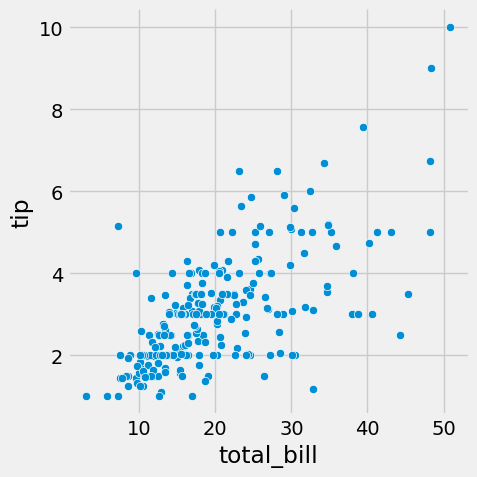

In [6]:
sns.relplot(x = 'total_bill' , y = 'tip', kind='scatter' , data = data)

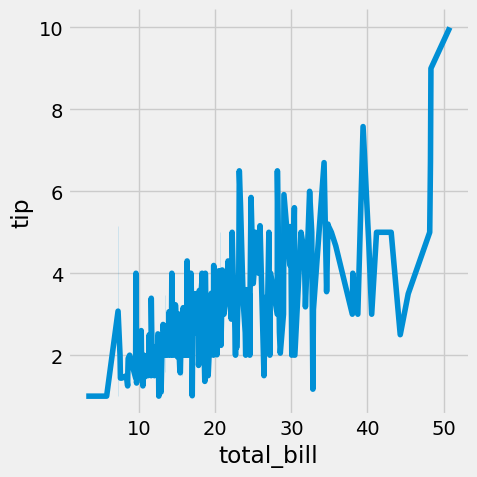

In [7]:
sns.relplot(x = 'total_bill' , y = 'tip', kind='line' , data = data)

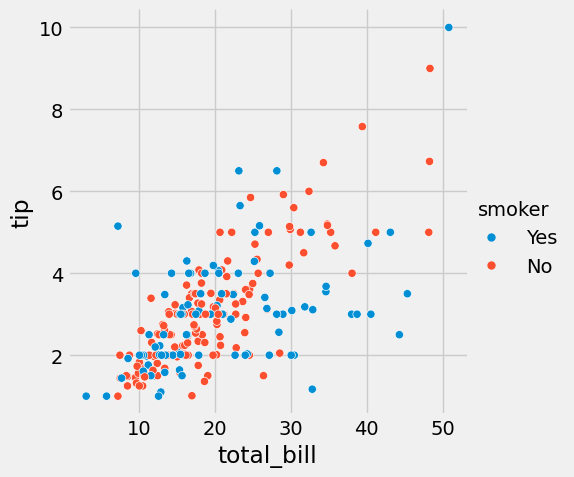

In [8]:
sns.relplot(x= 'total_bill', y='tip' , hue = 'smoker' , data = data )

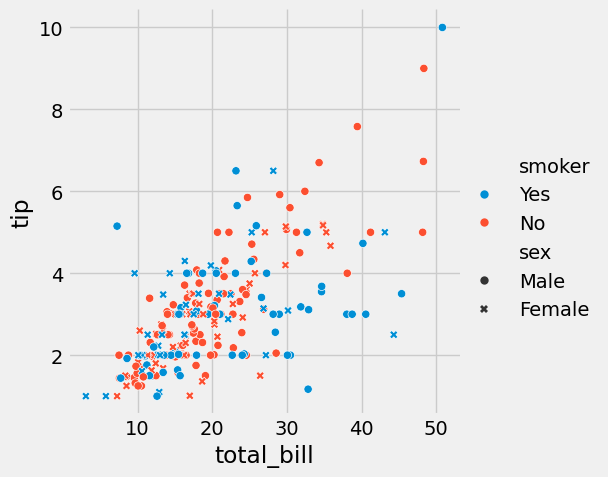

In [9]:
sns.relplot(x= 'total_bill', y='tip' , hue = 'smoker', style = 'sex', data = data )

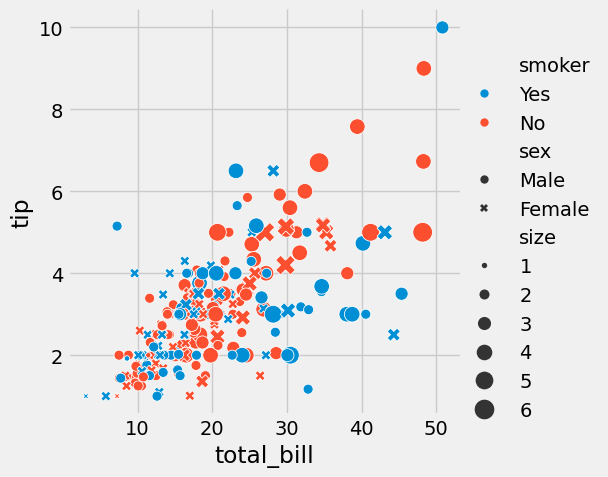

In [10]:
sns.relplot( x= 'total_bill', y='tip' , hue = 'smoker', style = 'sex' ,size = 'size' ,sizes = (15 , 200) , data = data )

<Axes: xlabel='total_bill', ylabel='tip'>

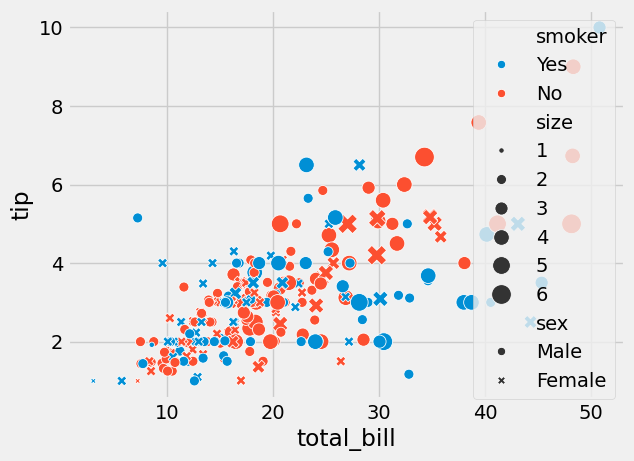

In [11]:
sns.scatterplot(x= 'total_bill', y='tip' , hue = 'smoker', style = 'sex' ,size = 'size' ,sizes = (15 , 200)  , data = data )

In [12]:
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


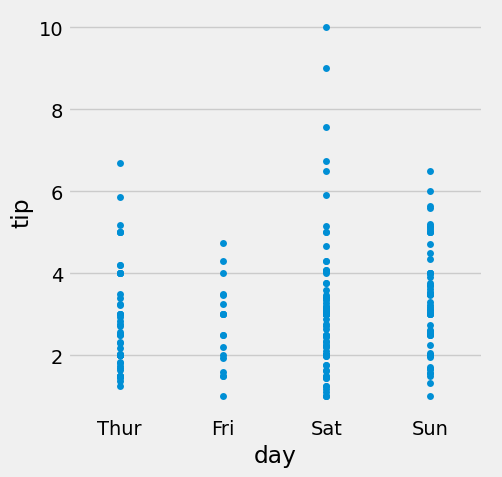

In [13]:
sns.catplot(x='day', y='tip' , kind='strip', jitter = 0 , data = data)

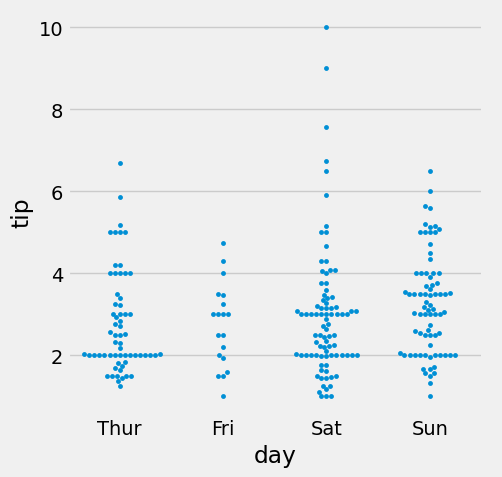

In [14]:
sns.catplot(x='day', y = 'tip', kind = 'swarm', size = 3.5 , data = data)

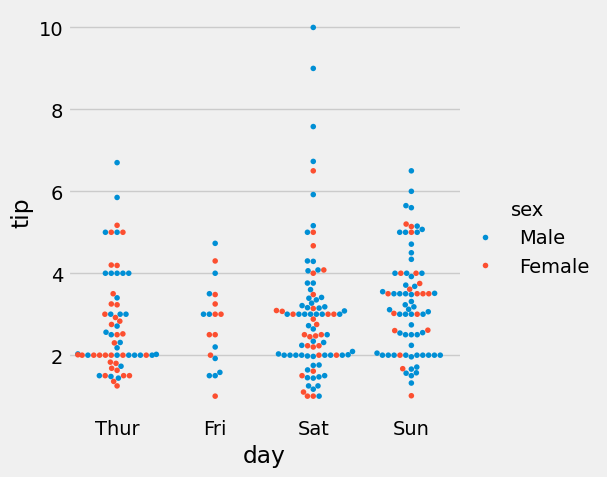

In [15]:
sns.catplot(x = 'day' , y = 'tip' , kind = 'swarm' , size = 4 , hue= 'sex' , data = data )

<Axes: xlabel='day', ylabel='tip'>

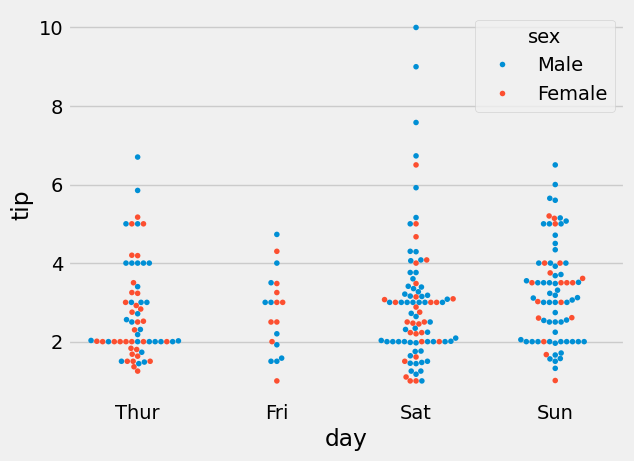

In [16]:
sns.swarmplot(x = 'day' , y = 'tip'  , size = 4 , hue= 'sex' , data = data )

<Axes: ylabel='tip'>

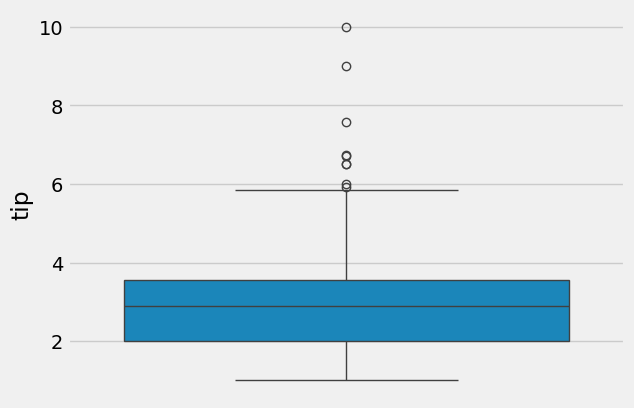

In [17]:
sns.boxplot(data['tip'])

<Axes: ylabel='total_bill'>

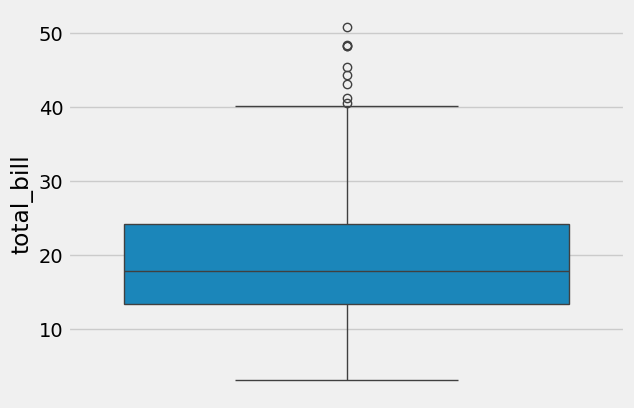

In [18]:
sns.boxplot(data['total_bill'])

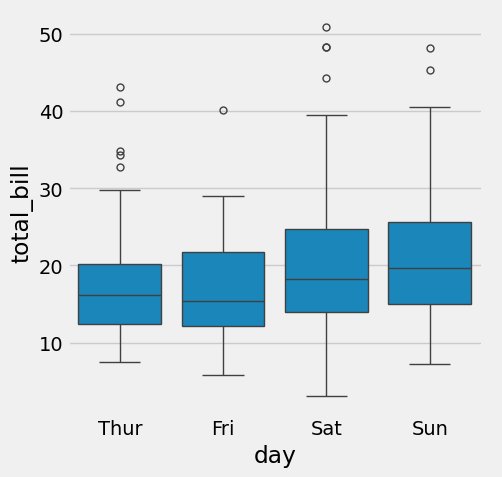

In [19]:
sns.catplot(x = 'day' , y = 'total_bill' , kind = 'box' , data = data)

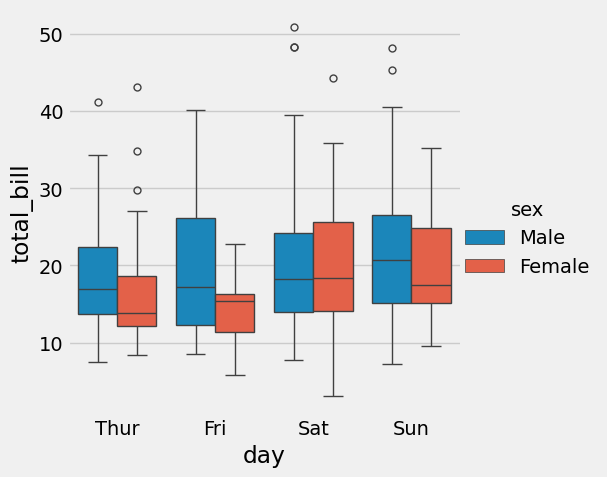

In [20]:
sns.catplot(x='day' , y='total_bill' , hue = 'sex', kind = 'box' , data= data)

<Axes: ylabel='total_bill'>

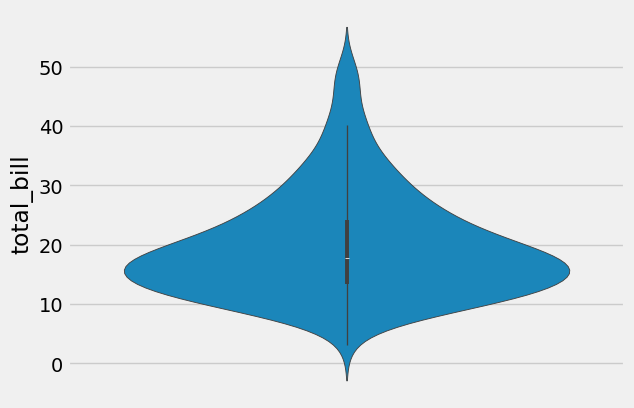

In [21]:
sns.violinplot(data['total_bill'])

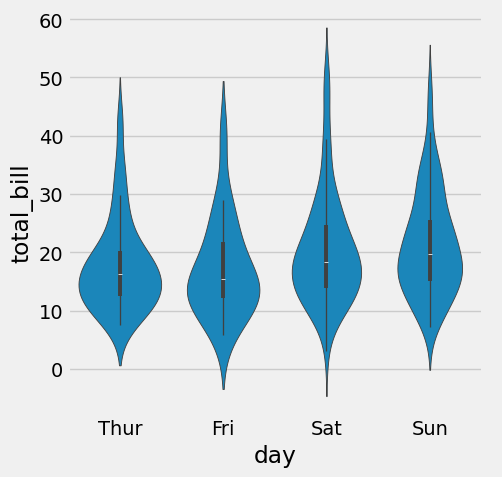

In [22]:
sns.catplot(x = 'day' , y = 'total_bill' , kind = 'violin' , data = data)

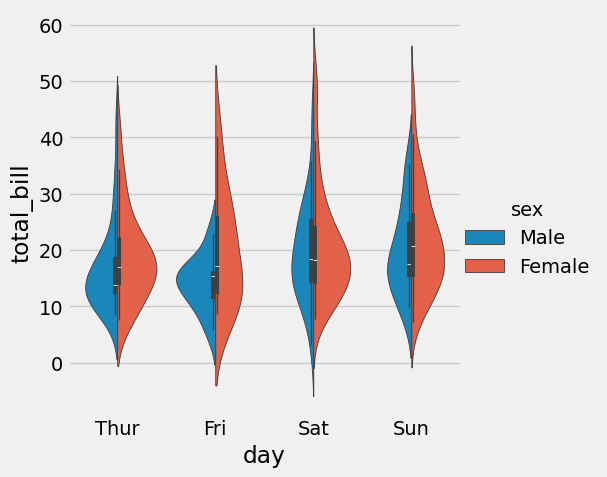

In [23]:
sns.catplot(x = 'day' , y = 'total_bill' , kind = 'violin', hue = 'sex' ,split = True , data = data) 

1. Scatter Plot — sns.scatterplot()

Math relation: Plots raw (x, y) pairs directly — visually represents correlation/covariance between two continuous variables. If points trend upward-right, correlation is positive; downward-right, negative; no pattern, near-zero correlation.

When to use: Two continuous numeric variables, checking for linear/non-linear relationship, clusters, or outliers.

python
sns.scatterplot(data=df, x='revenue', y='ad_spend', hue='region', size='employees', alpha=0.6)

Unique parameters:

hue — encode a 3rd categorical variable as color (e.g., compare correlation across regions)
size — encode a 4th numeric variable as point size
alpha — transparency, critical when points overlap heavily (dense data hides true density otherwise)
2. Strip Plot — sns.stripplot()

Math relation: Essentially a 1D scatter per category — shows every raw data point in its true value along one categorical axis. No aggregation, no summary stats — pure sample distribution.

When to use: Small-to-medium datasets where you want to see individual observations per category, not just a summary (good first look before boxplot/violin).

python
sns.stripplot(data=df, x='language', y='salary', jitter=True, hue='experience_level', dodge=True)

Unique parameters:

jitter — adds random horizontal noise so overlapping points at the same value become visible (without it, identical values stack invisibly on one line)
dodge — separates hue groups side-by-side instead of overlapping them at the same x position
3. Box Plot — sns.boxplot()

Math relation: Directly visualizes the five-number summary: minimum, Q1 (25th percentile), median, Q3 (75th percentile), maximum. Whiskers extend to 1.5 × IQR (IQR = Q3−Q1) by default; anything beyond that is plotted as an outlier point.

When to use: Comparing spread, median, and outliers across categories — best when you care about summary statistics, not distribution shape.

python
sns.boxplot(data=df, x='language', y='salary', whis=1.5, showfliers=True)

Unique parameters:

whis — changes the outlier threshold multiplier (e.g., whis=3 = more lenient, fewer points marked as outliers)
showfliers — toggle outlier points on/off
notch=True — adds a notch around the median showing a rough confidence interval, useful for judging if medians differ significantly between groups
4. Violin Plot — sns.violinplot()

Math relation: Combines boxplot summary stats with a Kernel Density Estimate (KDE) — a smoothed probability density function of the data, mirrored to form the violin shape. Unlike a boxplot, it reveals multimodality (e.g., two peaks) that a box/median alone would hide.

When to use: When distribution shape matters, not just summary stats — e.g., checking if salaries are bimodal (junior vs senior cluster) within one category.

python
sns.violinplot(data=df, x='language', y='salary', hue='experience_level', split=True, inner='quartile', bw_adjust=0.5)

Unique parameters:

split=True — draws two hue groups as mirrored halves of the same violin, for direct shape comparison
inner — what's drawn inside the violin: 'box', 'quartile', 'stick' (raw points), or None
bw_adjust — controls KDE smoothing bandwidth; lower = more detail/wigglier curve, higher = smoother/more generalized shape
5. Line Plot — sns.lineplot()

Math relation: At each x-value, aggregates all corresponding y-values (default: mean) and draws a shaded confidence interval band around it (default: bootstrapped 95% CI) — so it shows both central tendency and uncertainty over an ordered variable, usually time.

When to use: Trends over time or any ordered continuous variable, especially with repeated measurements per x-value (e.g., multiple readings per day).

python
sns.lineplot(data=df, x='month', y='revenue', hue='region', estimator='median', errorbar=('ci', 95))

Unique parameters:

estimator — aggregation function per x (mean, median, sum, or a custom function) — changes what the line actually represents
errorbar — controls the uncertainty band: ('ci', 95) for confidence interval, 'sd' for standard deviation, or None to remove the band entirely
markers=True, style= — adds distinct point markers per line, useful when lines overlap and color alone (hue) isn't enough to distinguish them

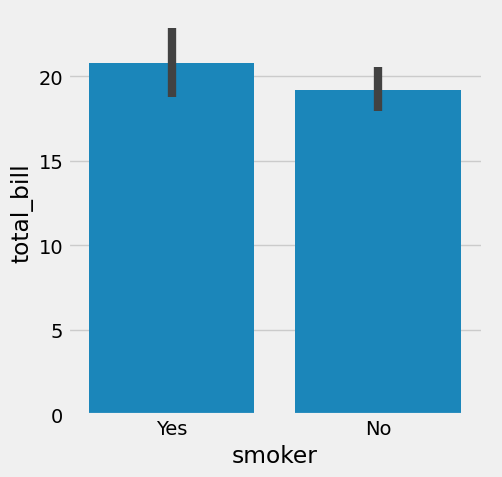

In [31]:
sns.catplot(x = 'smoker' , y = 'total_bill' , kind = 'bar' , data = data)

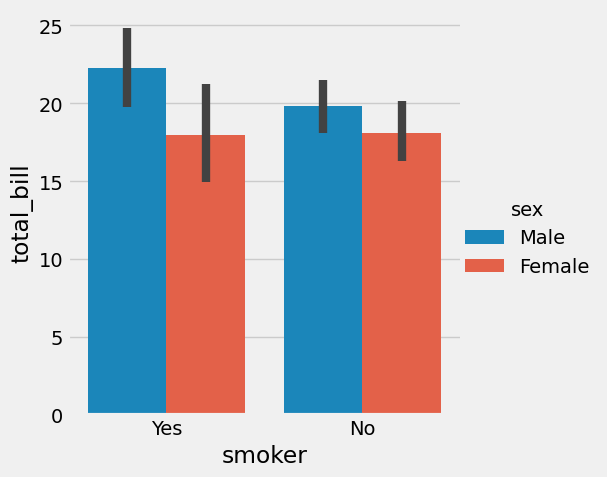

In [33]:
sns.catplot(x = 'smoker' , y = 'total_bill', kind = 'bar' , hue ='sex' , data = data)

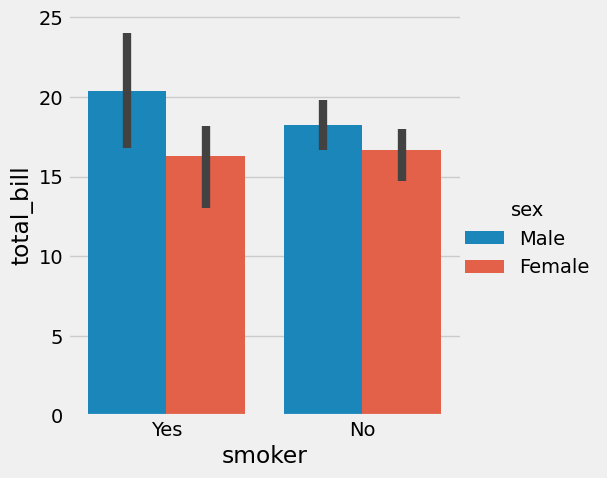

In [35]:
sns.catplot(x = 'smoker' , y = 'total_bill', kind = 'bar', estimator = np.median , hue ='sex' , data = data)

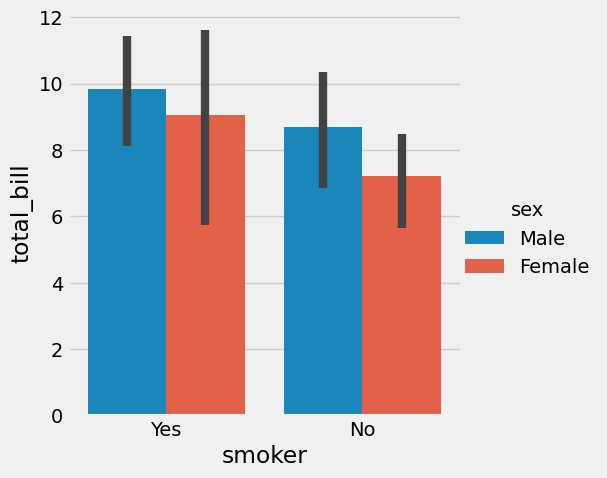

In [36]:
sns.catplot(x = 'smoker' , y = 'total_bill', kind = 'bar', estimator = np.std , hue ='sex' , data = data)

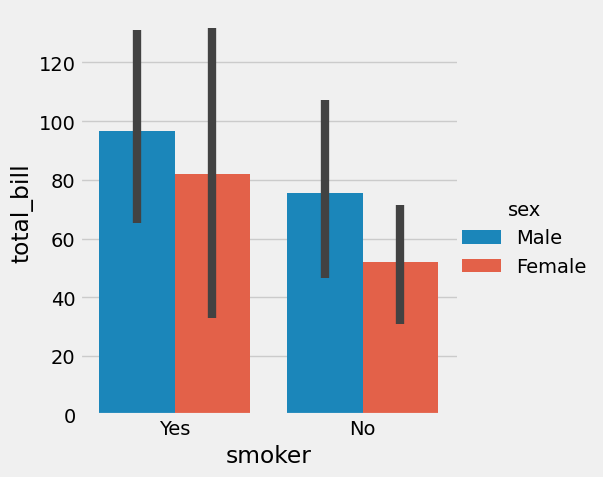

In [37]:
sns.catplot(x = 'smoker' , y = 'total_bill', kind = 'bar', estimator = np.var , hue ='sex' , data = data)

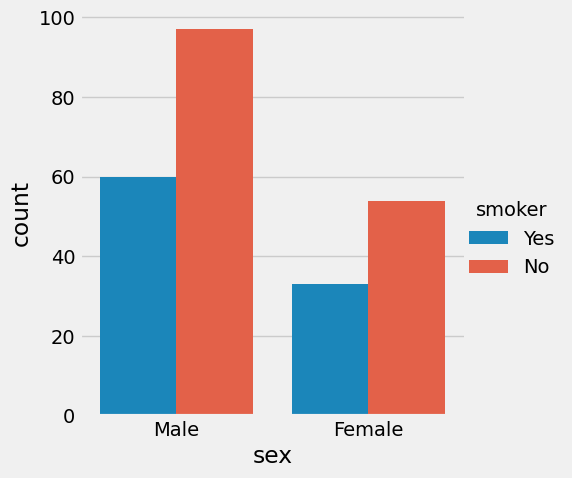

In [40]:
sns.catplot(x = 'sex' , kind = 'count' , data = data , hue = 'smoker')

In [5]:
flights = sns.load_dataset('flights')

In [6]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [7]:
x = flights.pivot_table(index = 'year' , columns = 'month' , values = 'passengers' , aggfunc='sum')

<Axes: xlabel='month', ylabel='year'>

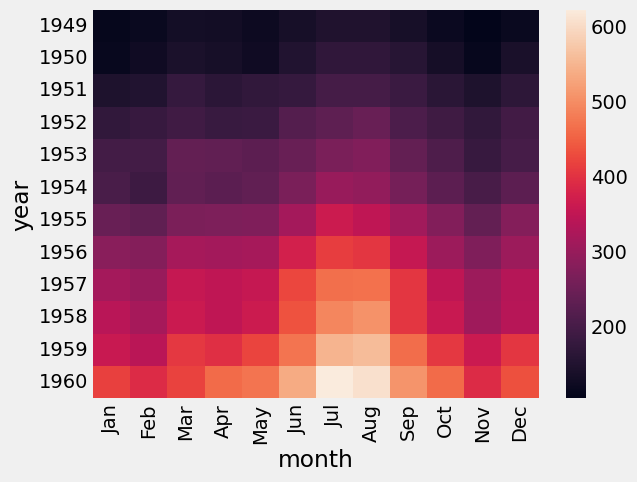

In [8]:
sns.heatmap(x)

<Axes: xlabel='month', ylabel='year'>

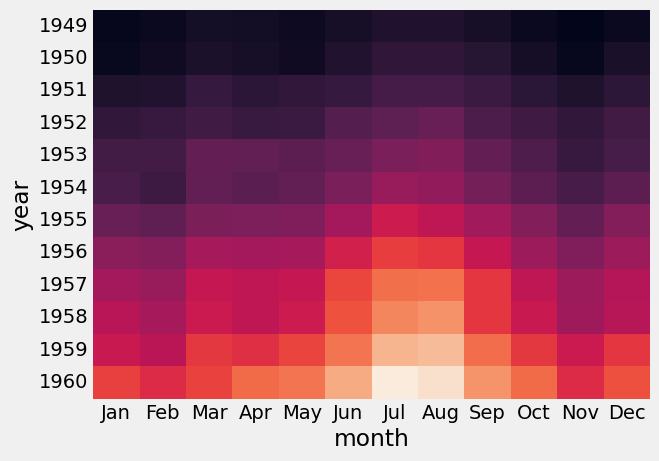

In [48]:
sns.heatmap(x , cbar = False ) 

<Axes: xlabel='month', ylabel='year'>

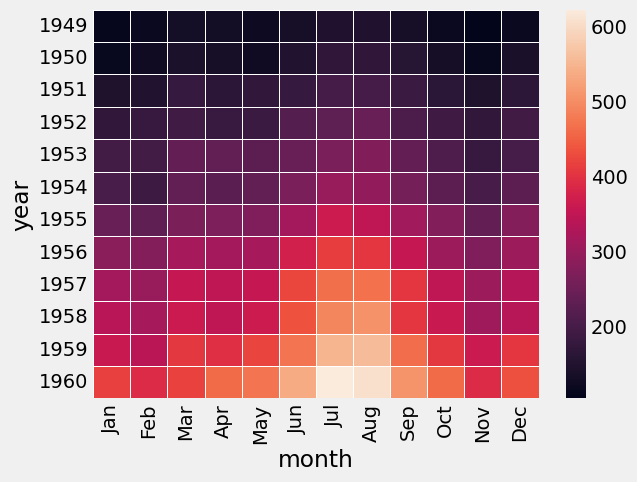

In [49]:
sns.heatmap(x , linewidth = 0.7)

<Axes: xlabel='month', ylabel='year'>

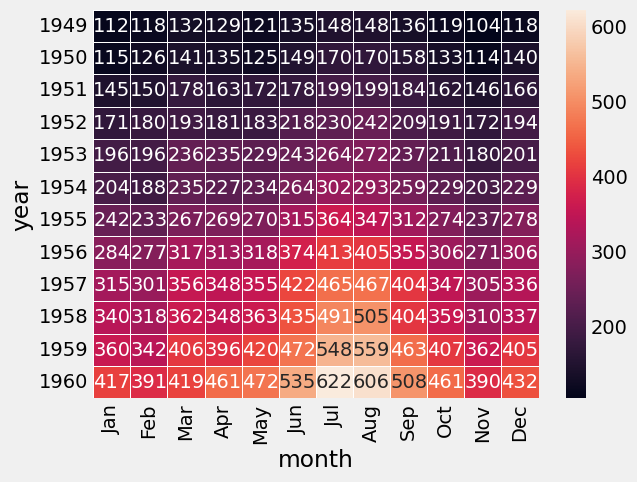

In [51]:
sns.heatmap(x , annot = True, linewidth = 0.7 , fmt = 'd')

<Axes: xlabel='month', ylabel='year'>

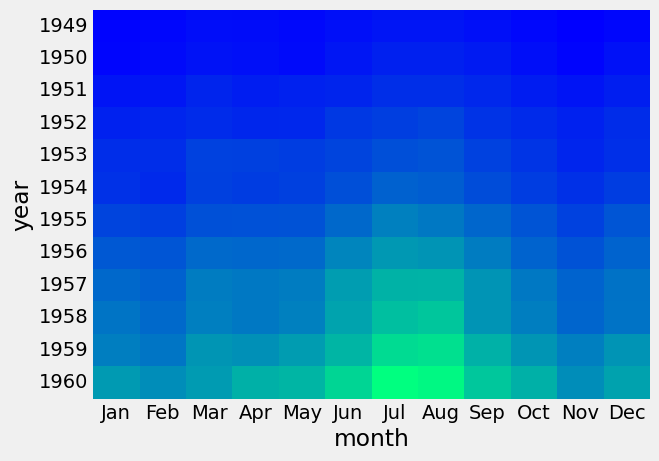

In [53]:
sns.heatmap(x , cbar = False , cmap = 'winter' ) 

In [57]:
#pip install scipy --break-system-packages

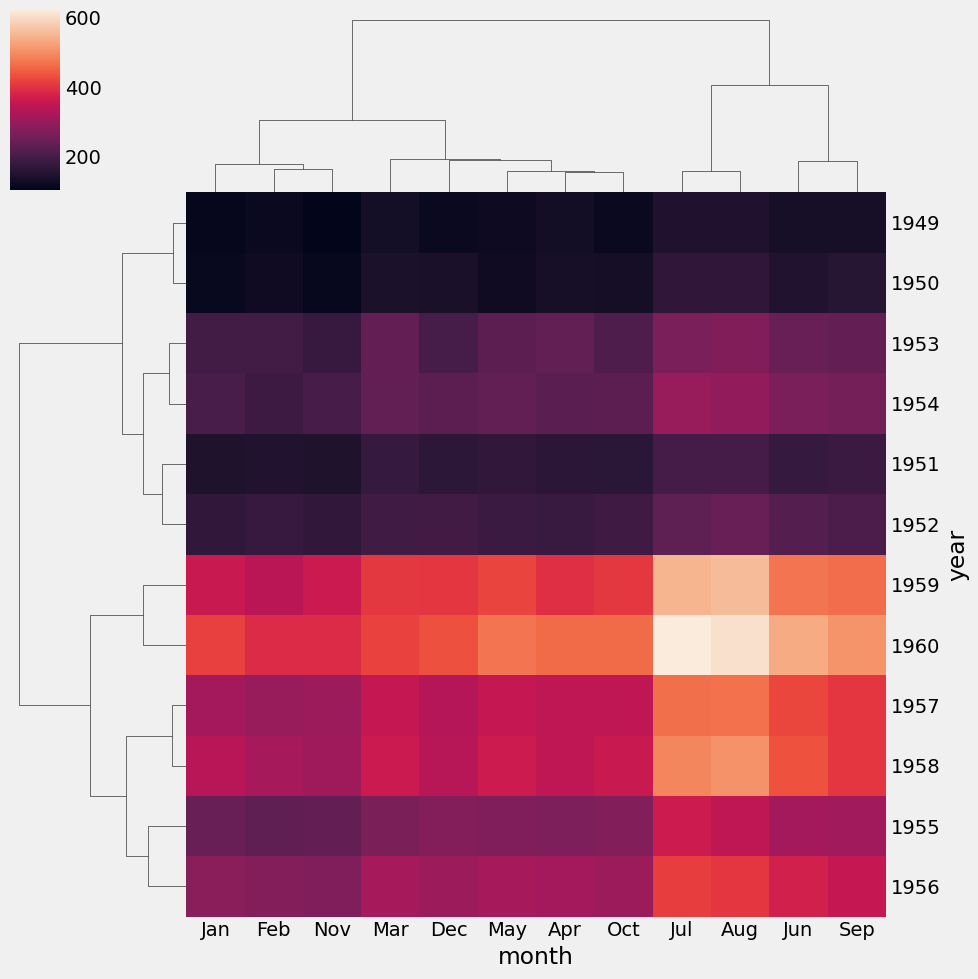

In [9]:
sns.clustermap(x)

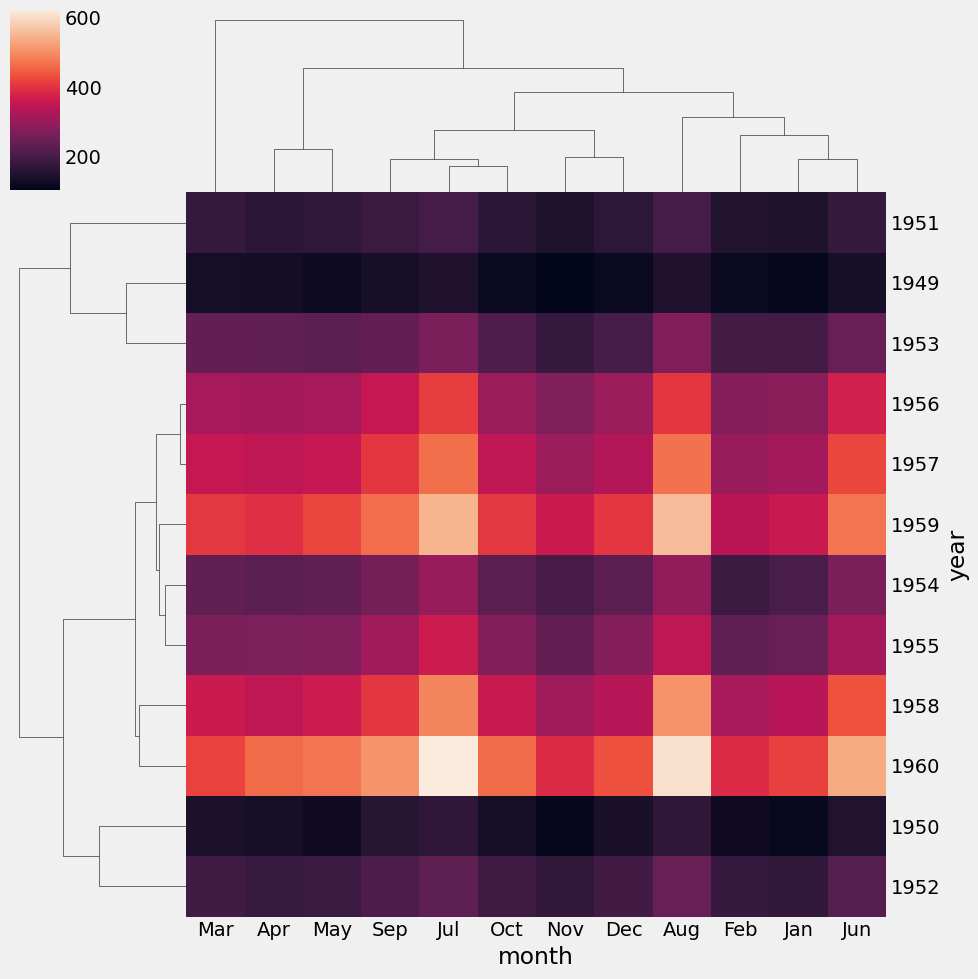

In [11]:
sns.clustermap(x , metric = 'correlation')

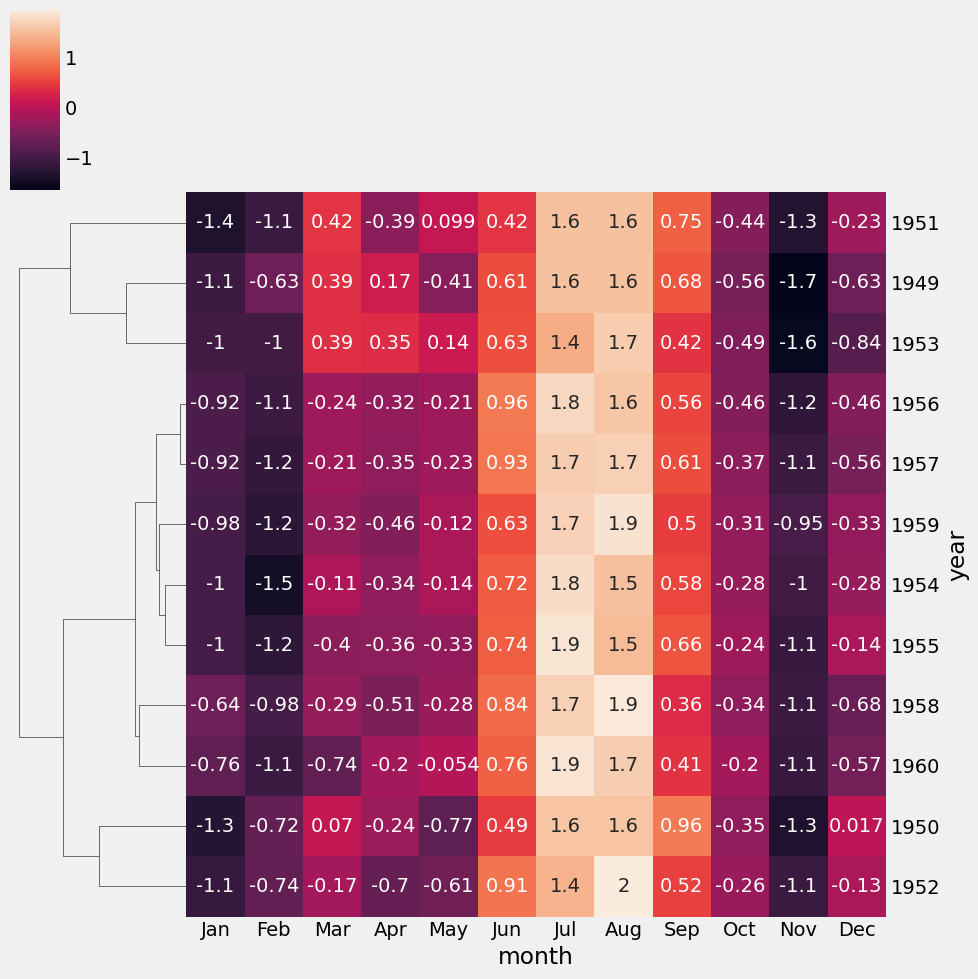

In [15]:
sns.clustermap(x ,z_score = 0 , annot = True, col_cluster = False, metric = 'correlation')

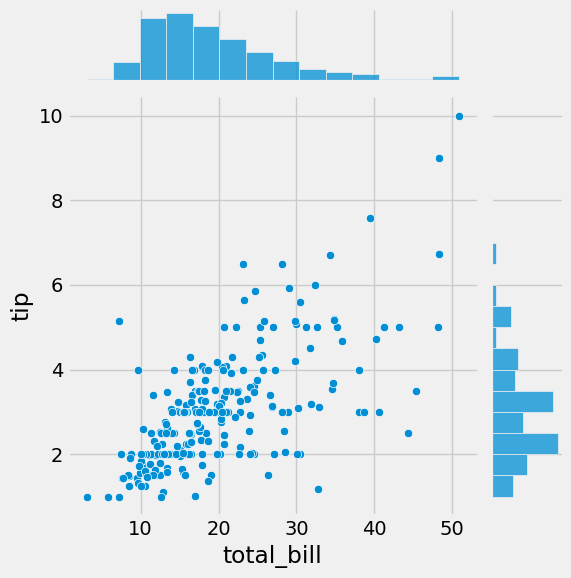

In [17]:
sns.jointplot(x = 'total_bill', y = 'tip' , data= data)

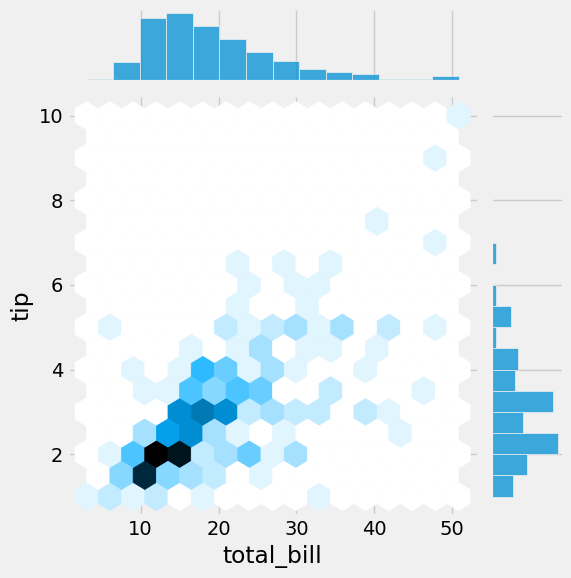

In [18]:
sns.jointplot(x='total_bill', y = 'tip' , kind = 'hex', data = data)

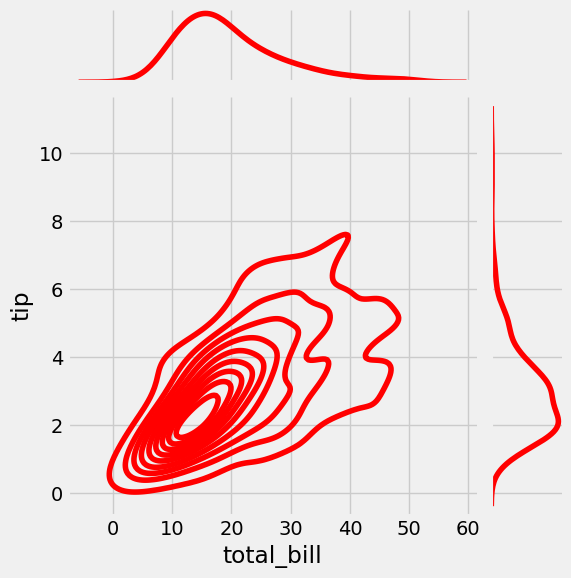

In [23]:
sns.jointplot(x = 'total_bill', y = 'tip', color = 'red', kind = 'kde' , data = data)

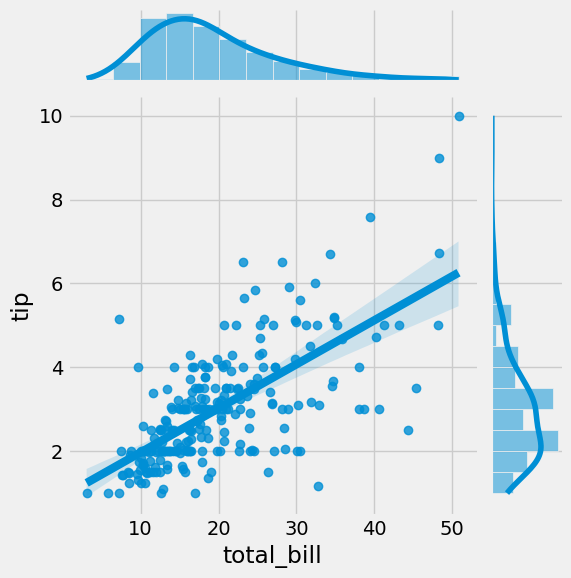

In [24]:
sns.jointplot(x = 'total_bill', y = 'tip'  ,kind = 'reg' , data = data )

In [25]:
iris = sns.load_dataset('iris')

In [26]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


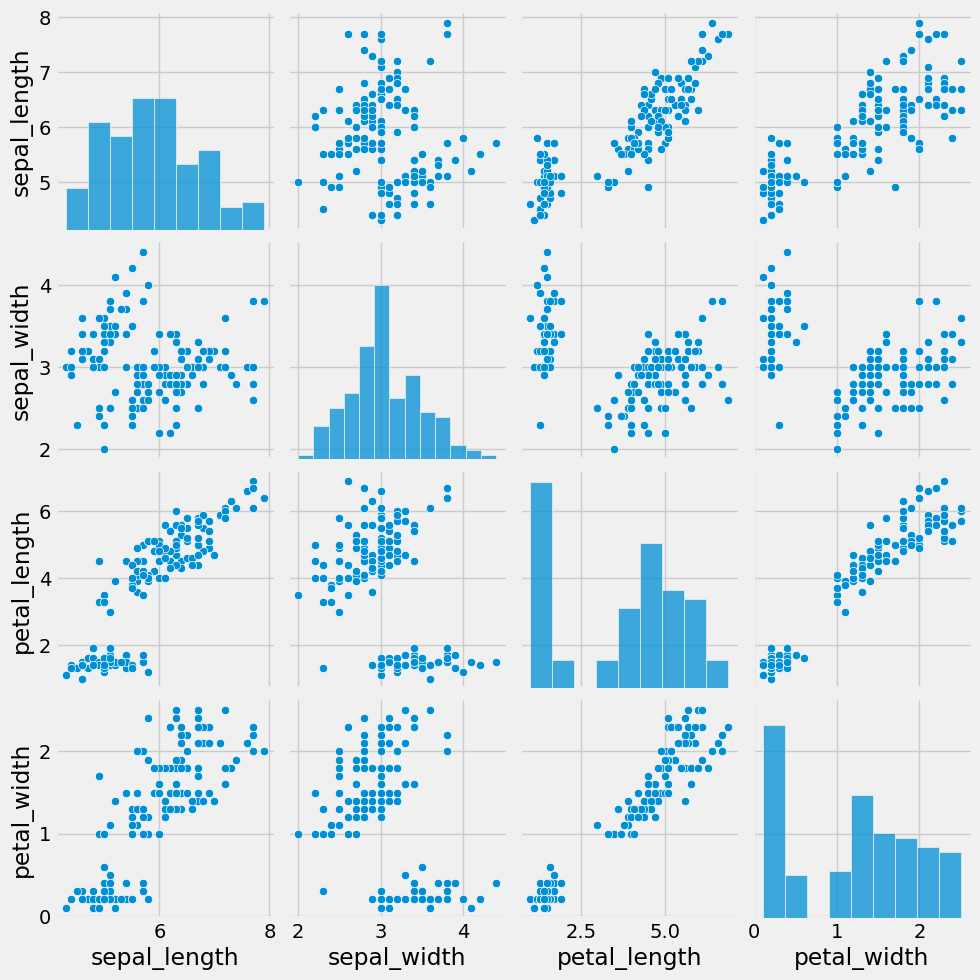

In [27]:
sns.pairplot(iris)

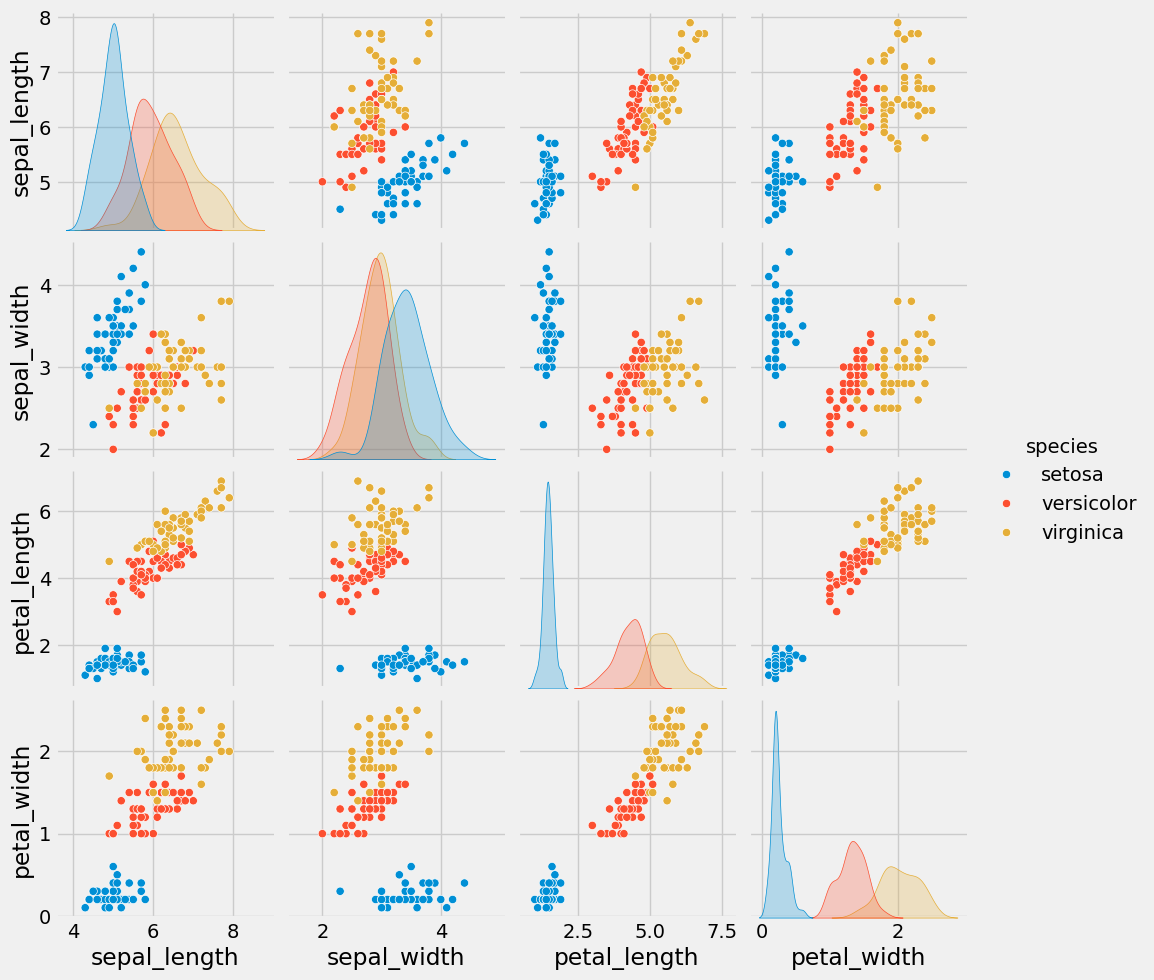

In [28]:
sns.pairplot(iris , hue  = 'species')

In [29]:
x = pd.read_csv('Data set/train.csv')

In [31]:
x

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


C:\Users\User\AppData\Local\Temp\ipykernel_18040\1539877588.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x['Age'])


<Axes: xlabel='Age', ylabel='Density'>

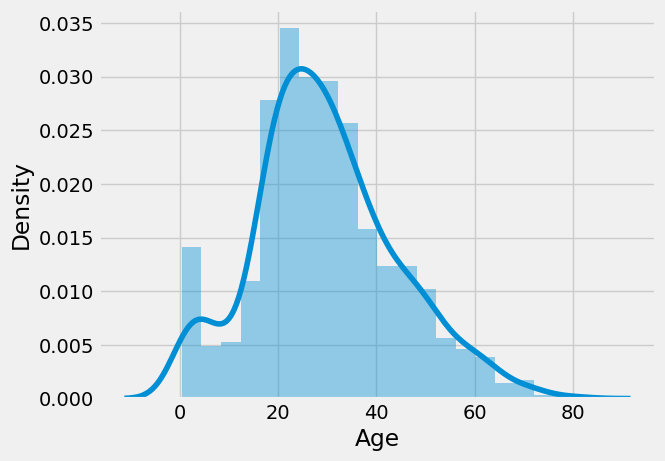

In [32]:
sns.distplot(x['Age'])